In [1]:
import xarray as xr
import numpy as np
import json
import torch

import os
import io
import pandas as pd
import glob
from PIL import Image


import matplotlib.pyplot as plt
from IPython.display import clear_output
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from tqdm import trange

from model.dit import get_dit
from omegaconf import OmegaConf


from ladcast.models.DCAE import AutoencoderDC
from ladcast.pipelines.utils import latent_ens_to_xarr
from ladcast.dataloader.utils import xarr_to_tensor, precompute_mean_std

lsm_path = 'ladcast/ladcast/static/240x121_land_sea_mask.pt'
orography_path = 'ladcast/ladcast/static/240x121_orography.pt'
normalization_json = 'ladcast/ladcast/static/ERA5_normal_1979_2017.json'

with open(normalization_json) as f:
   normalization_param_dict = json.load(f)

# lat: -90 to 90, lon: 0 to 358.5
if lsm_path:
    lsm_tensor = torch.load(lsm_path, weights_only=True) # (lat, lon)
    lsm_tensor = lsm_tensor[1:, :] # crop south pole (first row)
if orography_path:
    orography_tensor = torch.load(orography_path, weights_only=True)  # (4, lat, lon)
    orography_tensor = orography_tensor[:, 1:, :]  # crop south pole (first row)

static_conditioning_tensor = None
static_conditioning_tensor = lsm_tensor.unsqueeze(0) # (1, lat, lon)
static_conditioning_tensor = torch.cat(
    [static_conditioning_tensor, orography_tensor], dim=0
)

if static_conditioning_tensor is not None:
    static_mean_tensor = static_conditioning_tensor.mean(dim=(1, 2), keepdim=True) # (C, 1, 1)
    static_std_tensor = static_conditioning_tensor.std(dim=(1, 2), keepdim=True)
    static_conditioning_tensor = ((static_conditioning_tensor - static_mean_tensor)
                                    / static_std_tensor)


with open('ladcast/ladcast/static/ERA5_latent_normal_1979_2017_lat84.json') as f:
    latent_transform_args = json.load(f)
    latent_transform_args["target_std"] = 0.5

var_list =[
        # Atm variables
        'geopotential',
        'specific_humidity',
        'temperature',
        'u_component_of_wind',
        'v_component_of_wind',
        'vertical_velocity',
        # Start of single variables
        '10m_u_component_of_wind',
        '10m_v_component_of_wind',
        '2m_temperature',
        'mean_sea_level_pressure',
        'sea_surface_temperature',
        'total_precipitation_6hr',
            ]

mean_tensor, std_tensor = precompute_mean_std(normalization_param_dict, var_list)

# eval enabled by default
encdec_model = AutoencoderDC.from_pretrained("tonyzyl/ladcast", subfolder="V0.1.X/DCAE")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
encdec_model = encdec_model.to(device)
static_conditioning_tensor = static_conditioning_tensor.to(device)

era5_ds = xr.open_zarr("gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr")
era5_ds = era5_ds[var_list]

with open('yeartime_dictionary.json', 'r') as json_file:
    dictionary_yeartime = json.load(json_file)

/home/jovyan/.mlspace/envs/arsen_ladcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Encode condition context, 4 weather maps

In [2]:
### initialize prediction model with data from range [timestamp_start, timestamp_end]

timestamp_start = np.datetime64('2021-12-01T06:00:00.000000000')
timestamp_end = timestamp_start + np.timedelta64(18, 'h')


selected_ds = era5_ds.sel(time=slice(timestamp_start, timestamp_end), latitude=slice(-88.5, 90))
selected_ds = selected_ds.load()

input_tensor = xarr_to_tensor(
    selected_ds,
    variable_names=var_list,
    normalization_param_dict=normalization_param_dict,
)

with torch.no_grad():
        encoded_tensor = encdec_model.encode(
            input_tensor.permute(1, 0, 2, 3).to(device),
            static_conditioning_tensor=static_conditioning_tensor.unsqueeze(0).repeat(4, 1, 1, 1),
                ).latent

numpy_in = encoded_tensor.permute(0, 2, 3, 1).unsqueeze(0).cpu().numpy()

# result_ds = latent_ens_to_xarr(
#         torch.from_numpy(numpy_in.transpose(0, 4, 1, 2, 3)).to("cpu"),
#         encdec_model=encdec_model,
#         mean_tensor=mean_tensor,
#         std_tensor=std_tensor,
#         timestamp=str(timestamp_end).split(":")[0].replace("T", "").replace("-", ""),
#         variable_names=var_list,
#     )

# print(
#     timestamp_start, np.sqrt(np.mean((result_ds['2m_temperature'].values[0, 0, 0] -\
# selected_ds['2m_temperature'].values[0].transpose(1, 0)) ** 2)).item()   
# )

## 2. Initialize Marchuk, Get predictions

In [5]:
#### Marchuk
conf = OmegaConf.load('configs/model.yaml')
dit = get_dit(conf.model.dit_params)
dit = dit.to(device)

VIDEO_LENGTH = 16
state_dict = torch.load(
    f"weights/model.ckpt",
    weights_only=False,
    map_location=torch.device('cpu')
)
dit.load_state_dict(state_dict)

@torch.no_grad()
def generate(model, ref_image, shape, device, num_steps, text_embed):
    img = torch.randn(*shape, device=device)
    time = torch.ones(shape[0], device=device)
    time_step = 1. / num_steps
    for _ in range(num_steps):
        pred_velocity = model(torch.cat([ref_image, img], 1), text_embed, time)
        img = img - time_step * pred_velocity[:, -VIDEO_LENGTH:]
        time = time - time_step
    return img



bs = 20 ## ensemble size
shape = (bs, VIDEO_LENGTH , 15, 30, 84)
num_steps = 20
ROLLOUT_TIME = 8
full_yeartime_seq = [timestamp_start]
for _ in range(200):
    full_yeartime_seq.append(full_yeartime_seq[-1] + np.timedelta64(6, 'h'))
input_yeartime = np.array([dictionary_yeartime[str(timestep_year_)[5:]] for timestep_year_ in full_yeartime_seq])

prev = encoded_tensor.unsqueeze(0).repeat(bs, 1, 1, 1, 1).to(device).permute(0, 1, 3, 4, 2)
data_cond = input_yeartime[:20]
results_to_save = [prev[:, 3:4].cpu().numpy()]

for rollout_idx in trange(ROLLOUT_TIME):
    bs_text_embed = torch.tensor([data_cond]).to(device)
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        images = generate(dit, prev, shape, device, num_steps, bs_text_embed)

    results_to_save.append(images.cpu().numpy())
    prev = images[:, 12:]
    data_cond = input_yeartime[(rollout_idx + 1) * 16: (rollout_idx + 1) * 16 + 20]


  0%|          | 0/8 [00:00<?, ?it/s]/tmp/ipykernel_660128/625783952.py:41: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  bs_text_embed = torch.tensor([data_cond]).to(device)
100%|██████████| 8/8 [03:42<00:00, 27.78s/it]


## Decode results

In [6]:
### Not optimized by GPU memory

# numpy_in_first = np.concatenate(results_to_save, 1)
# numpy_in = numpy_in_first.transpose(0, 4, 1, 2, 3)
# timestamp_str = str(timestamp_end).split(":")[0].replace("T", "").replace("-", "")
# result_ds = latent_ens_to_xarr(
#     torch.from_numpy(numpy_in).to("cpu"),
#     encdec_model=encdec_model,
#     mean_tensor=mean_tensor,
#     std_tensor=std_tensor,
#     timestamp=timestamp_str,
#     variable_names=var_list,
#     )
# result_ens_mean_ds = result_ds.mean(dim='idx')

In [7]:
## Optimized by GPU memory, working sequantial
numpy_in_first = np.concatenate(results_to_save, 1)
result = []
for i in range(numpy_in_first.shape[1]):
    numpy_in = numpy_in_first[:, i:i+1].transpose(0, 4, 1, 2, 3)
    timestamp_str = str(timestamp_end).split(":")[0].replace("T", "").replace("-", "")
    result_ds = latent_ens_to_xarr(
        torch.from_numpy(numpy_in).to("cpu"),
        encdec_model=encdec_model,
        mean_tensor=mean_tensor,
        std_tensor=std_tensor,
        timestamp=timestamp_str,
        variable_names=var_list,
        )
    # result_ens_mean_ds = result_ds.mean(dim='idx')
    result.append(result_ds.assign_coords(prediction_timedelta=result_ds.prediction_timedelta + np.timedelta64(6 * i, 'h')))
result_ds = xr.concat(result, dim='prediction_timedelta')
result_ens_mean_ds = result_ds.mean(dim='idx')

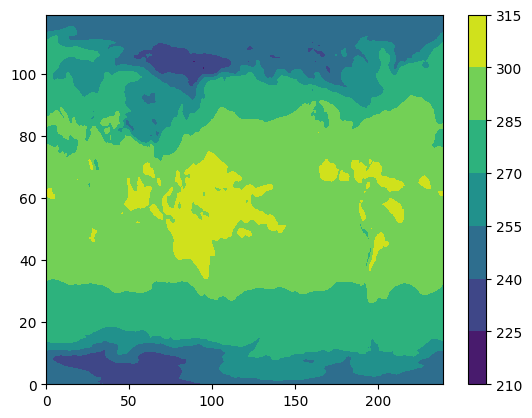

In [8]:
### reconstruction delta = 0.0
plt.contourf(result_ds["2m_temperature"].sel(time=result_ds.time[0]).values[0, 0])
plt.colorbar()

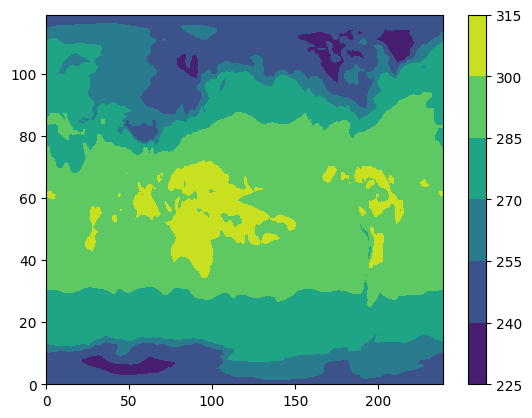

In [9]:
### 30 day prediction
plt.contourf(result_ds["2m_temperature"].sel(time=result_ds.time[0]).values[0, 30 * 4])
plt.colorbar()

## Compare to ground truth

In [10]:
rmse_res = []
for i in trange(len(result_ens_mean_ds["2m_temperature"].prediction_timedelta)):
    pred_val = result_ens_mean_ds["2m_temperature"].values[0, i]
    real_val = era5_ds.sel(
        time=result_ens_mean_ds.time[0] + np.timedelta64(6 * i, "h"), latitude=slice(-88.5, 90)
        )["2m_temperature"].values.transpose(1, 0)
    rmse_res.append(np.sqrt(np.mean((pred_val - real_val)**2)))

100%|██████████| 129/129 [03:26<00:00,  1.60s/it]


Text(0, 0.5, 'RMSE error')

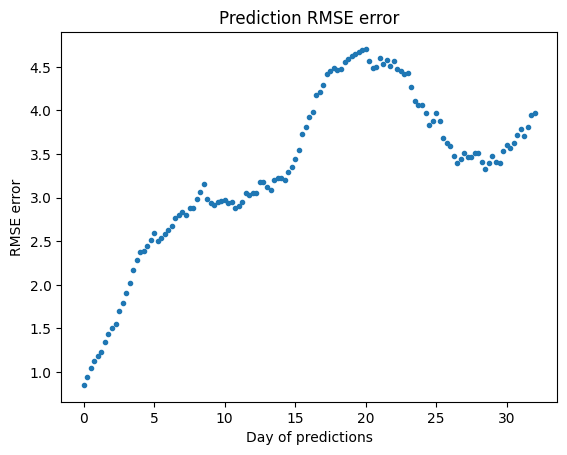

In [13]:
x_array = np.arange(len(rmse_res)) * 6 / 24.  ### in days
plt.plot(x_array, rmse_res, ".")
plt.title("Prediction RMSE error")
plt.xlabel("Day of predictions")
plt.ylabel("RMSE error")

Text(0, 0.5, 'RMSE error')

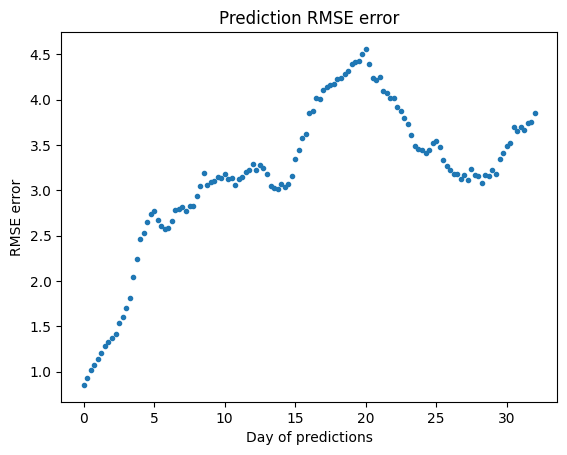

In [9]:
x_array = np.arange(len(rmse_res)) * 6 / 24.  ### in days
plt.plot(x_array, rmse_res, ".")
plt.title("Prediction RMSE error")
plt.xlabel("Day of predictions")
plt.ylabel("RMSE error")

## Get Weather Video

In [10]:
os.makedirs("tmp_frames", exist_ok=True)
lats, lons = result_ens_mean_ds.latitude.values, result_ens_mean_ds.longitude.values

variable = "specific_humidity"
data = result_ds[variable].sel(idx=0, level=700).values[0] ### select single trajectory


data = data * 1000
norm = mcolors.Normalize(vmin=data.min(), vmax=data.max())
fontsize = 12

frames = []
for n_days in range(data.shape[0]):
    fig, ax = plt.subplots(
        1, 1, figsize=(6, 4),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True
        )

    ims = []
    im = ax.pcolormesh(
        lons, lats, data[n_days],
        transform=ccrs.PlateCarree(),
        cmap="magma",
        norm=norm,
    )
    ax.coastlines(color="white", linewidth=1)
    # ax.text(-0.04, 0.5, f'+ {days[i]} days', va='bottom', ha='center',
    #     rotation='vertical', rotation_mode='anchor', fontsize=fontsize+2,
    #     transform=ax.transAxes)
    ax.text(-175, 77, f' {n_days // 4} day', fontsize=14, color='white')
    ims.append(im)
    fig.savefig(f'tmp_frames/tmp_frame_{n_days}.png', dpi=100, bbox_inches="tight")
    fig.clf()

# cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
#                     pad=0.02, aspect=30, fraction=0.05, shrink=0.54)
# cbar.set_label('Q700 (g/kg)', fontsize=fontsize+2)
# cbar.ax.tick_params(labelsize=fontsize)

frames = [Image.open(element) 
          for element in sorted(glob.glob("tmp_frames/*"), key=lambda x: int(x.split("/")[1].split("_")[-1][:-4]))]
frames[0].save(
    f"{variable}.gif",
    save_all=True,
    append_images=frames[1:],
    duration=200, # Duration in milliseconds
    loop=0        # 0 means loop forever
)

clear_output(wait=True)

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

...

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>